#### environment

In [1]:
import os 
import numpy as np
from numpy import full
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from predict_loop_functions import predict_loop, noise_iterations, filter_region
from scipy.stats import linregress

In [2]:
# use image stack from july16 already saved
image_stack = np.load('saved_inputs_outputs//image_stack_july16.npy')

In [3]:
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
           1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

#### predictions

In [4]:
d3_sum, d3_mean, d3_var, d3_labels = predict_loop('dynamic', image_stack, 3, [[4,7]])

In [5]:
d15_sum, d15_mean, d15_var, d15_labels = predict_loop('dynamic', image_stack, 15, [[4,7]])

In [6]:
d30_sum, d30_mean, d30_var, d30_labels = predict_loop('dynamic', image_stack, 30, [[4,7]])

In [7]:
c3_sum, c3_mean, c3_var, c3_labels = predict_loop('constant', image_stack, 3, [[4,7]])

In [8]:
c15_sum, c15_mean, c15_var, c15_labels = predict_loop('constant', image_stack, 15, [[4,7]])

In [9]:
c30_sum, c30_mean, c30_var, c30_labels = predict_loop('constant', image_stack, 30, [[4,7]])

In [10]:
dbin_sum, dbin_mean, dbin_var, dbin_labels = predict_loop('dynamic', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [11]:
cbin_sum, cbin_mean, cbin_var, cbin_labels = predict_loop('constant', image_stack, 0, [[4,7]], stochastic_bin_param = True)

In [ ]:
# save predictions to predictions_july21
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin']:
    for type in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        np.save(path, arr = globals()[file_name])

#### load predictions

In [4]:
for noise in ['c3', 'c15', 'c30', 'd3', 'd15', 'd30', 'dbin', 'cbin']:
    for type in ['_sum', '_mean', '_var', '_labels']:
        file_name = noise + type + '.npy'
        var_name = noise + type
        path = 'saved_inputs_outputs//predictions_july21//' + file_name
        globals()[var_name] = np.load(path)

In [70]:
c3_labels.shape

(1, 7493)

In [71]:
c3_labels

array([[2, 2, 2, ..., 1, 1, 1]])

#### filtering by region (function completed)

In [6]:
def get_region(region_input: int, label_mapping, array):
    region_indices = [i for i, region in enumerate(label_mapping) if region == region_input]
    if array.ndim == 2: return array[:, region_indices]
    else: return array[:,:, region_indices]

In [7]:
c3_dynamic_r1 = get_region(3, c3_labels_test, c3_mean)

NameError: name 'c3_labels_test' is not defined

In [69]:
c3_dynamic_r1.shape

(5, 387)

In [59]:
c3_mean.shape

(5, 7493)

In [57]:
c3_labels_test.shape

(7493,)

In [47]:
c3_dynamic_r1.shape

(5, 0, 7493)

In [53]:
c3_labels_test = c3_labels

In [54]:
c3_labels_test = c3_labels_test.reshape(c3_labels_test.shape[1],)

In [55]:
c3_labels_test[:5]

array([2, 2, 2, 2, 2])

In [6]:
c3_mean.shape

(5, 7493)

In [7]:
print('Brain Region Labels Value Counts\n' \
      '--------------------------------')
print(pd.DataFrame(c3_labels).T.value_counts())

Brain Region Labels Value Counts
--------------------------------
0
1    5312
2     983
4     811
3     387
Name: count, dtype: int64


In [8]:
# make each region 100 neurons
region3 = []

for i, region in enumerate(c3_labels_test):
    if region == 3: region3.append([i, int(region)])

In [9]:
region3

[[513, 3],
 [514, 3],
 [515, 3],
 [900, 3],
 [940, 3],
 [1000, 3],
 [1001, 3],
 [1718, 3],
 [2101, 3],
 [2170, 3],
 [2173, 3],
 [2195, 3],
 [2197, 3],
 [2218, 3],
 [2219, 3],
 [2220, 3],
 [2221, 3],
 [2222, 3],
 [2223, 3],
 [2224, 3],
 [2225, 3],
 [2226, 3],
 [2227, 3],
 [2228, 3],
 [2229, 3],
 [2230, 3],
 [2231, 3],
 [2232, 3],
 [2233, 3],
 [2234, 3],
 [2235, 3],
 [2236, 3],
 [2237, 3],
 [2238, 3],
 [2239, 3],
 [2240, 3],
 [2241, 3],
 [2242, 3],
 [2245, 3],
 [2247, 3],
 [2248, 3],
 [2249, 3],
 [2250, 3],
 [2251, 3],
 [2252, 3],
 [2253, 3],
 [2255, 3],
 [2256, 3],
 [2257, 3],
 [2258, 3],
 [2259, 3],
 [2260, 3],
 [2261, 3],
 [2262, 3],
 [2266, 3],
 [2267, 3],
 [2268, 3],
 [2269, 3],
 [2270, 3],
 [2271, 3],
 [2272, 3],
 [2273, 3],
 [2274, 3],
 [2275, 3],
 [2276, 3],
 [2277, 3],
 [2278, 3],
 [2279, 3],
 [2280, 3],
 [2281, 3],
 [2291, 3],
 [2292, 3],
 [2293, 3],
 [2294, 3],
 [2295, 3],
 [2306, 3],
 [2307, 3],
 [2308, 3],
 [2309, 3],
 [2312, 3],
 [2850, 3],
 [2858, 3],
 [2885, 3],
 [2906, 3

In [10]:
region3_indices = [i for i, region in region3]

In [11]:
region3_mean = c3_mean[:, region3_indices]

In [12]:
region3_mean.shape

(5, 387)

shape matches value_counts() for region

#### filter function fix

In [15]:
test1, test2, test3, test_labels = predict_loop('no noise', image_stack, 0, [[4,7]], noise_seeds = 3, num_frames = 2)

In [16]:
type(test_labels[0])

pandas.core.series.Series

In [17]:
test_labels_flat = np.array(test_labels[0]).flatten()

In [6]:
type(test_labels_flat)

numpy.ndarray

In [7]:
for x in test_labels_flat: 
    if not (type(x) != int): print(x)

In [18]:
test1_r2 = filter_region(2, test_labels_flat, test1)

In [19]:
test1_r2.shape

(5, 3, 983)

In [20]:
pd.DataFrame(test_labels).T.value_counts()

brain_area
1             5312
2              983
4              811
3              387
Name: count, dtype: int64

#### sigma versus mean

In [5]:
c3_sum.shape

(5, 100, 7493)

In [6]:
c3_mean.shape

(5, 7493)

In [7]:
c3_mean_r1 = filter_region(1, c3_labels, c3_mean)

In [8]:
c3_mean_r1.shape

(5, 5312)

In [9]:
print('Value Counts for Scan Labels, c3_mean')
print(pd.DataFrame(c3_labels).T.value_counts())

Value Counts for Scan Labels, c3_mean
0
1    5312
2     983
4     811
3     387
Name: count, dtype: int64


In [10]:
def line_plot_mean(array, neurons): # input mean output from predict_loop()
    final_array = np.empty(shape = len(neurons))
    for i, neuron in enumerate(neurons):
        avg = np.mean(array[:,neuron])
        final_array[i] = avg
    return final_array

In [65]:
d3_mean.shape

(5, 7493)

In [64]:
d3_labels.shape

(1, 7493)

In [66]:
test_concat = np.concatenate((d3_mean, d3_labels), axis = 0)
test_concat.shape

(6, 7493)

In [77]:
test_concat[5,:]

array([2., 2., 2., ..., 1., 1., 1.])

In [80]:
test_filter = np.where(test_concat[5] == 1)
test_filter[0]

array([  15,   18,   19, ..., 7490, 7491, 7492])

In [81]:
test_filter = d3_mean[:,test_filter[0]]

In [82]:
test_filter.shape

(5, 5312)

In [94]:
def filter_region(region_input: int, num_images: int, label_mapping, array):
    """
    Parameters
    ----------
    region_input: int
        specified region to output
    num_images: int
        number of images used for predict_loop()
    label_mapping: label
        mapping output from scans()
    array: np.array
        array to filter

    Returns
    -------
    array
        filtered array where brain region is equal to region_input
    """
    
    concat_array = np.concatenate((array, label_mapping), axis=0)
    region_indices = np.where(concat_array[num_images] == region_input)

    return array[..., region_indices[0]]

In [95]:
test = filter_region(1, 5,d3_labels, d3_mean)
test.shape

(5, 5312)

In [26]:
d3_mean_r1.shape

(5, 5312)

In [42]:
print(d3_mean_r1.shape)
print(np.unique(d3_mean, axis=1).shape)  # Number of unique columns

(5, 5312)
(5, 7493)


In [40]:
np.mean(d3_mean_r1[:, 34])

np.float64(20.408281984090806)

In [38]:
d3_mean_r1[:, 100]

array([31.18711713, 12.16073485, 20.83473612, 20.8231984 , 17.03562341])

In [15]:
# region 1 dynamic data
d3_mean_r1 = filter_region(1, d3_labels, d3_mean)
d15_mean_r1 = filter_region(1, d3_labels, d15_mean)
d30_mean_r1 = filter_region(1, d3_labels, d30_mean)
dbin_mean_r1 = filter_region(1, d3_labels, dbin_mean)


In [16]:
# region 1 dynamic, plotting data
plot_mean_d30_r1 = line_plot_mean(d30_mean_r1, [i for i in range(100)])
plot_mean_d15_r1 = line_plot_mean(d15_mean_r1, [i for i in range(100)])
plot_mean_d3_r1 = line_plot_mean(d3_mean_r1, [i for i in range(100)])
plot_mean_dbin_r1 = line_plot_mean(dbin_mean_r1, [i for i in range(100)])

In [14]:
# region 1 constant data
c3_mean_r1 = filter_region(1, c3_labels, c3_mean)
c15_mean_r1 = filter_region(1, c3_labels, c15_mean)
c30_mean_r1 = filter_region(1, c3_labels, c30_mean)
cbin_mean_r1 = filter_region(1, c3_labels, cbin_mean)


In [19]:
# region 1 constant, plotting data
plot_mean_c30_r1 = line_plot_mean(c30_mean_r1, [i for i in range(100)])
plot_mean_c15_r1 = line_plot_mean(c15_mean_r1, [i for i in range(100)])
plot_mean_c3_r1 = line_plot_mean(c3_mean_r1, [i for i in range(100)])
plot_mean_cbin_r1 = line_plot_mean(cbin_mean_r1, [i for i in range(100)])

C:\Users\joshf\AppData\Local\Temp\ipykernel_10336\1780885969.py:29: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)
C:\Users\joshf\AppData\Local\Temp\ipykernel_10336\1780885969.py:32: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)


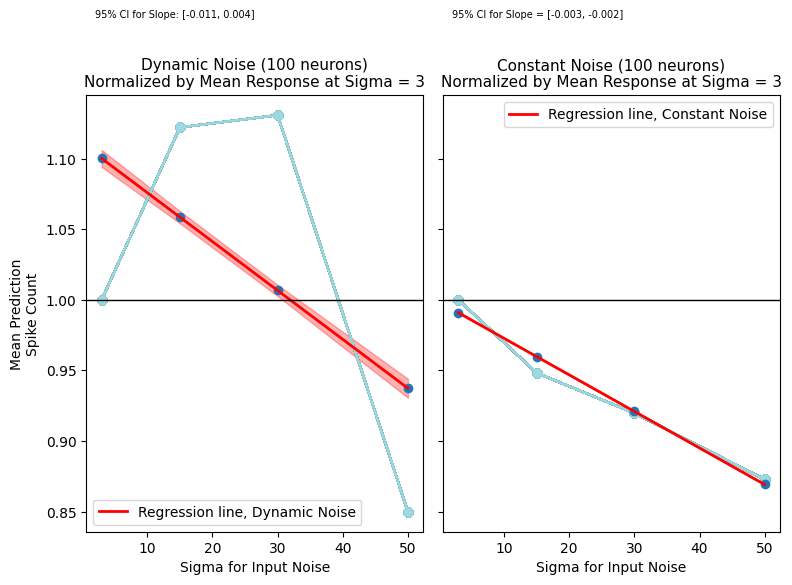

In [29]:
fig, axes = plt.subplots(1,2, figsize = (8,6), sharey = True)

sigmas = np.array([3, 15, 30, 50]) # making stochastic bin. 50 here, what should it be?

dynamic_means = [plot_mean_d3_r1, plot_mean_d15_r1, plot_mean_d30_r1, plot_mean_dbin_r1] 
constant_means = [plot_mean_c3_r1, plot_mean_c15_r1, plot_mean_c30_r1, plot_mean_cbin_r1] 

colors = plt.cm.tab20(np.linspace(0, 1, 100))  # 100 colors for 100 neurons

for i in range(100):
    dynamic_y = [plot_mean_d3_r1[i], plot_mean_d15_r1[i], plot_mean_d30_r1[i], plot_mean_dbin_r1[i]] / plot_mean_d3_r1[i]
    constant_y = [plot_mean_c3_r1[i], plot_mean_c15_r1[i], plot_mean_c30_r1[i], plot_mean_cbin_r1[i]] / plot_mean_c3_r1[i]

    axes[0].plot(sigmas, dynamic_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])

    axes[1].plot(sigmas, constant_y, marker='o', linestyle='-', alpha=0.5, color = colors[i])
    
dynamic_mean_y = np.mean(dynamic_means, axis=1) / np.mean(plot_mean_d3_r1)  
constant_mean_y = np.mean(constant_means, axis=1) / np.mean(plot_mean_c3_r1)

slope_dyn, intercept_dyn, r_value_dyn, p_value_dyn, std_err_dyn = linregress(sigmas, dynamic_mean_y)
y_pred_dyn = intercept_dyn + slope_dyn * sigmas

slope_con, intercept_con, r_value_con, p_value_con, std_err_con = linregress(sigmas, constant_mean_y)
y_pred_con = intercept_con + slope_con * sigmas


axes[0].plot(sigmas, y_pred_dyn, 'o')
axes[0].plot(sigmas, y_pred_dyn, 'r-', label='Regression line, Dynamic Noise', color = 'red', linewidth = 2)

axes[1].plot(sigmas, y_pred_con, 'o')
axes[1].plot(sigmas, y_pred_con, 'r-', label='Regression line, Constant Noise', color = 'red', linewidth = 2)

# error band/SE
dyn_se = std_err_dyn * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
con_se = std_err_con * np.sqrt(1/len(sigmas) + (sigmas - np.mean(sigmas))**2 / np.sum((sigmas - np.mean(sigmas))**2))
axes[0].fill_between(sigmas, y_pred_dyn - 1.96*dyn_se, y_pred_dyn + 1.96*dyn_se, color='red',  alpha = 0.3)
axes[1].fill_between(sigmas, y_pred_con - 1.96*con_se, y_pred_con + 1.96*con_se, color='red', alpha = 0.3)

axes[0].text(2, 1.2, f'95% CI for Slope: [{slope_dyn - 1.96 * std_err_dyn:.3f}, {slope_dyn + 1.96 * std_err_dyn:.3f}]', fontsize = 7) # x1.96 for 95% CI
axes[1].text(2, 1.2, f'95% CI for Slope = [{slope_con - 1.96 * std_err_con:.3f}, {slope_con + 1.96 * std_err_con:.3f}]', fontsize = 7)

axes[0].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[1].axhline(y=1, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel('Sigma for Input Noise')
axes[0].set_title('Dynamic Noise (100 neurons)\nNormalized by Mean Response at Sigma = 3', fontsize = 11)
axes[1].set_title('Constant Noise (100 neurons)\nNormalized by Mean Response at Sigma = 3', fontsize = 11)
axes[0].set_ylabel('Mean Prediction\nSpike Count')
axes[1].set_xlabel('Sigma for Input Noise')
axes[0].legend()
axes[1].legend()
plt.tight_layout()
plt.show()